# Ridge Regression and the Lasso

In [6]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from ISLP import load_data
from adjustText import adjust_text


In [7]:
Hitters = load_data('Hitters')
np.isnan(Hitters['Salary']).sum()

np.int64(59)

We see that `Salary` is missing for 59 players. The
`dropna()` method of data frames removes all of the rows that have missing
values in any variable.

In [8]:
Hitters = Hitters.dropna()
Hitters.shape

(263, 20)

In [9]:
Y = np.array(Hitters['Salary'])
X = pd.get_dummies(Hitters.drop('Salary', axis=1), drop_first=True).astype(float)
feature_names = X.columns
X = np.asarray(X)
X.shape

(263, 19)

## Ridge Regression

We fit ridge regression across a grid of $\alpha$ values ranging
from very large (effectively the null model) to very small (approaching
least squares). We use `StandardScaler` in a pipeline rather than
standardizing by hand, and use `skl.Ridge` directly.

To visualize the regularization path, we loop over the grid and collect
the standardized coefficients at each $\alpha$.

In [12]:
scaler = StandardScaler()
alphas = np.logspace(6, -2, 100) # These are the regularization penalty terms, usually you need to have them on a log scale

coefs = []
for a in alphas:
    ridge = skl.Ridge(alpha=a) # This creates a ridge model with a certain alpha

    # We will combine it with the standard scaler

    pipe = Pipeline(steps=[('scaler', StandardScaler()),
                           ('ridge', ridge)])
    pipe.fit(X, Y)

    # Then we save the coefficients

    coefs.append(pipe.named_steps['ridge'].coef_)

# Create a data frame showing how the coeficients change, this 
# solution path shows the path the coefficients take as the penalty is 

soln_path = pd.DataFrame(coefs,
                         columns=feature_names,
                         index=-np.log(alphas)) # Notice the minus sign here. This is sometimes done, a conention in ISLP
soln_path.index.name = 'negative log(alpha)'
soln_path

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
negative log(alpha),,,,,,,,,,,,,,,,,,,
-13.815511,0.046661,0.051861,0.040537,0.049632,0.053125,0.052473,0.047342,0.062180,0.064877,0.062041,0.066504,0.067011,0.057885,0.035544,0.003008,-0.000641,-0.001673,-0.022782,-0.000323
-13.629443,0.056182,0.062445,0.048806,0.059760,0.063965,0.063183,0.056999,0.074866,0.078114,0.074699,0.080073,0.080684,0.069694,0.042803,0.003623,-0.000773,-0.002011,-0.027437,-0.000386
-13.443376,0.067640,0.075185,0.058757,0.071951,0.077010,0.076072,0.068618,0.090132,0.094044,0.089932,0.096403,0.097138,0.083904,0.051543,0.004362,-0.000932,-0.002416,-0.033042,-0.000461
-13.257308,0.081428,0.090516,0.070729,0.086620,0.092708,0.091583,0.082598,0.108501,0.113212,0.108262,0.116052,0.116937,0.101002,0.062063,0.005252,-0.001123,-0.002901,-0.039792,-0.000548
-13.071241,0.098014,0.108962,0.085130,0.104269,0.111592,0.110246,0.099413,0.130597,0.136272,0.130312,0.139690,0.140755,0.121568,0.074727,0.006324,-0.001355,-0.003481,-0.047918,-0.000651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3.860900,-290.727681,336.582795,37.108469,-59.420362,-26.309418,134.770097,-17.444389,-386.263374,90.533635,-11.529830,474.221481,255.924720,-212.829197,78.761821,53.572577,-22.226560,31.260131,-58.476181,-12.423250
4.046968,-290.789150,336.790313,37.232619,-59.611894,-26.423634,134.820836,-17.317830,-387.078202,89.916997,-11.967363,475.303911,256.712435,-213.005133,78.761698,53.599832,-22.215726,31.258442,-58.465774,-12.411054
4.233035,-290.840410,336.963879,37.336416,-59.772132,-26.519119,134.863210,-17.212456,-387.753637,89.394260,-12.334434,476.210236,257.372834,-213.152555,78.761605,53.622431,-22.206636,31.256968,-58.457092,-12.400797


We plot the paths to get a sense of how the coefficients vary with $\alpha$.

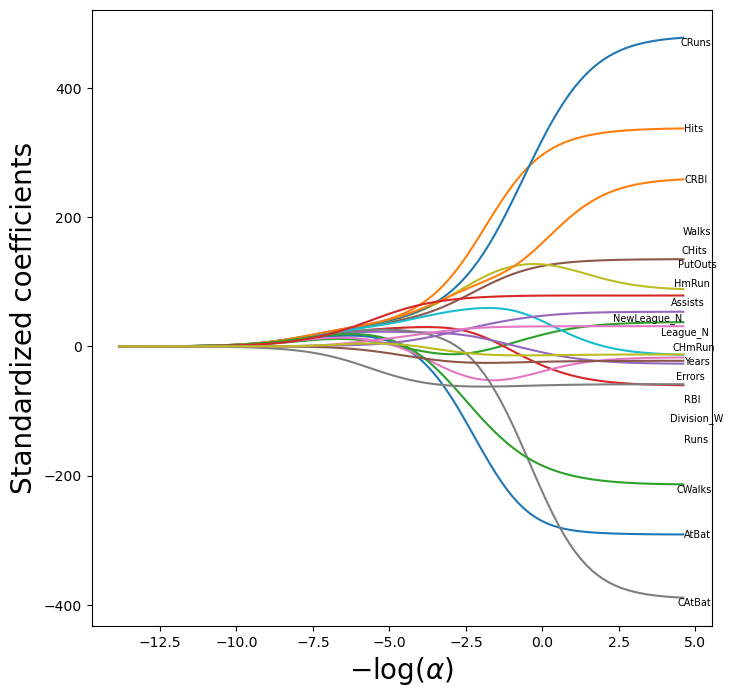

In [13]:

path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.set_xlabel(r'$-\log(\alpha)$', fontsize=20) # used a raw string here because of some formatting issues
ax.set_ylabel('Standardized coefficients', fontsize=20)

# Here is code to put the labels on the right side of this graph
# It starts at 0 because we are plotting the negative of the log penalty
x_max = soln_path.index[-1]
texts = []
for col in soln_path.columns:
    y_end = soln_path[col].iloc[-1]
    texts.append(ax.text(x_max, y_end, col, fontsize=7, va='center'))

adjust_text(texts, ax=ax, only_move={'text': 'y'}, force_text=(0.5, 2.0)); # This is like some tools in R for annotating plots with text

We expect the coefficient estimates to be much smaller, in terms of
$\ell_2$ norm, when a large value of $\alpha$ is used, as compared to
when a small value of $\alpha$ is used. We display the $\ell_2$ norm
at two different points along the path.

In [14]:
beta_hat = soln_path.iloc[39]
alphas[39], np.linalg.norm(beta_hat)

(np.float64(705.4802310718638), np.float64(84.41074083895582))

In [16]:
beta_hat = soln_path.iloc[59]
alphas[59], np.linalg.norm(beta_hat)

(np.float64(109.74987654930568), np.float64(137.8071887412311))

### Estimating Test Error of Ridge Regression
Choosing an *a priori* value of $\alpha$ for ridge regression is
difficult if not impossible. We will want to use the validation method
or cross-validation to select the tuning parameter. The `Pipeline()` approach can be used in
`skm.cross_validate()` with either a validation method
or $k$-fold cross-validation.

We fix the random state of the splitter
so that the results obtained will be reproducible.

In [17]:
# Now we will do cross validation to estimate the test error of ridge regression

# Here we have picked the penalty in advance

ridge = skl.Ridge(alpha=0.01)
scaler = StandardScaler()
pipe = Pipeline(steps=[('scaler', scaler), ('ridge', ridge)])

validation = skm.ShuffleSplit(n_splits=1,
                              test_size=0.5,
                              random_state=0)
results = skm.cross_validate(pipe,
                             X,
                             Y,
                             scoring='neg_mean_squared_error',
                             cv=validation)
-results['test_score']

array([133821.45286659])

Obviously choosing $\alpha=0.01$ is arbitrary, so we will use cross-validation or the validation-set
approach to choose the tuning parameter $\alpha$.
The object `GridSearchCV()` allows exhaustive
grid search to choose such a parameter.

We first use the validation set method
to choose $\alpha$.

In [ ]:

param_grid = {'ridge__alpha': alphas}
grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=validation,
                        scoring='neg_mean_squared_error')
grid.fit(X, Y)
grid.best_params_['ridge__alpha']

np.float64(0.8302175681319736)

Alternatively, we can use 5-fold cross-validation.

In [21]:
K = 5
kfold = skm.KFold(K, random_state=0, shuffle=True)


grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(X, Y)
grid.best_params_['ridge__alpha']

np.float64(2.6560877829466896)

We now plot the cross-validated MSE as a function of $-\log(\alpha)$, which has shrinkage decreasing from left
to right.

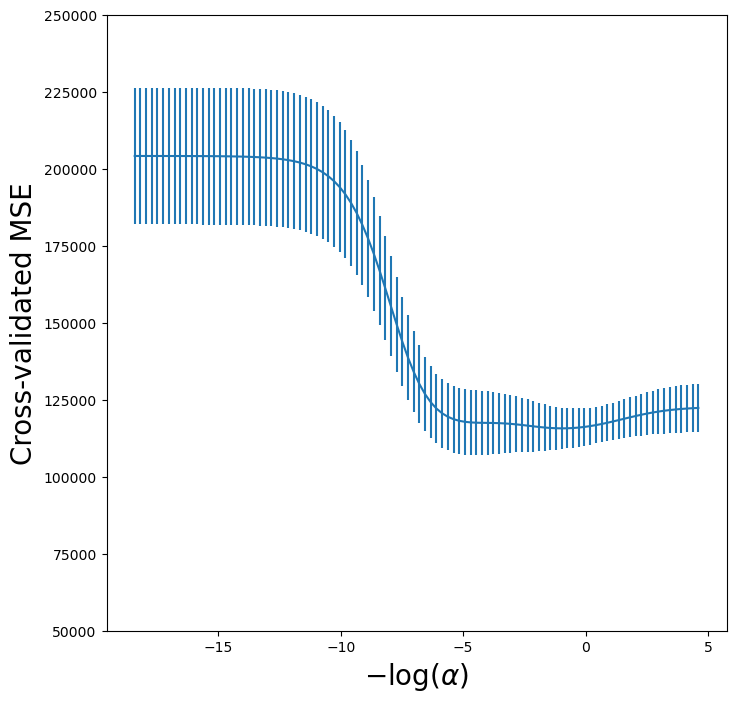

In [23]:
ridge_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(alphas),
            -grid.cv_results_['mean_test_score'],
            yerr=grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylim([50000,250000])
ax.set_xlabel(r'$-\log(\alpha)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

One can cross-validate different metrics to choose a parameter. The default
metric for `skl.Ridge()` is $R^2$.
Let's compare $R^2$ to MSE for cross-validation here.

In [24]:
grid_r2 = skm.GridSearchCV(pipe,
                           param_grid,
                           cv=kfold)
grid_r2.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...alpha=0.01))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ridge__alpha': array([1.0000...00000000e-02])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

Let's plot the results for cross-validated $R^2$.

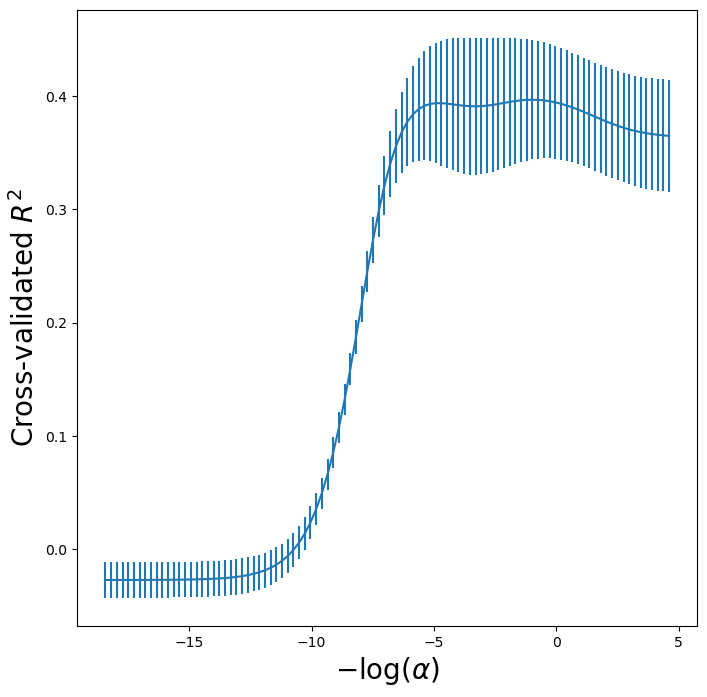

In [26]:
r2_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(alphas),
            grid_r2.cv_results_['mean_test_score'],
            yerr=grid_r2.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_xlabel(r'$-\log(\alpha)$', fontsize=20)
ax.set_ylabel('Cross-validated $R^2$', fontsize=20);

### Fast Cross-Validation with RidgeCV
`RidgeCV` can also accept an explicit `cv` argument for $K$-fold
cross-validation, similar to `GridSearchCV` but using the specialized
ridge solver. We use this to replicate the grid search above.

In [27]:
ridgeCV = skl.RidgeCV(alphas=alphas, cv=kfold,
                      scoring='neg_mean_squared_error')
pipeCV = Pipeline(steps=[('scaler', StandardScaler()),
                         ('ridge', ridgeCV)])
pipeCV.fit(X, Y)
tuned_ridge = pipeCV.named_steps['ridge']
tuned_ridge.alpha_

np.float64(2.6560877829466896)

### Evaluating Test Error of Cross-Validated Ridge
Choosing $\alpha$ using cross-validation provides a single regression
estimator. It is therefore reasonable to estimate what its test error
is. We run into a problem here in that cross-validation will have
*touched* all of its data in choosing $\alpha$, hence we have no
further data to estimate test error. A compromise is to do an initial
split of the data into two disjoint sets: a training set and a test set.
We then fit a cross-validation
tuned ridge regression on the training set, and evaluate its performance on the test set.
Below, we use
75% for training and 25% for test, with the estimator being ridge
regression tuned using 5-fold cross-validation.

In [28]:
outer_valid = skm.ShuffleSplit(n_splits=1,
                               test_size=0.25,
                               random_state=1)
inner_cv = skm.KFold(n_splits=5,
                     shuffle=True,
                     random_state=2)
ridgeCV = skl.RidgeCV(alphas=alphas, cv=inner_cv,
                      scoring='neg_mean_squared_error')
pipeCV = Pipeline(steps=[('scaler', StandardScaler()),
                         ('ridge', ridgeCV)])

results = skm.cross_validate(pipeCV,
                             X,
                             Y,
                             cv=outer_valid,
                             scoring='neg_mean_squared_error')
-results['test_score']

array([130976.43780562])

### RidgeCV with Built-In Leave-One-Out Cross-Validation
When `cv=None` (the default), `RidgeCV` uses an efficient closed-form formula
(generalized cross-validation) to compute the leave-one-out CV error for
ridge regression. This is much faster than explicitly looping over folds---the
LOO solution for all $\alpha$ values is computed in a single matrix decomposition.

Setting `store_cv_results=True` stores the LOO squared errors per sample
per $\alpha$ in the attribute `cv_results_`, which has shape `(n_samples, n_alphas)`.

In [15]:
ridgeLOO = skl.RidgeCV(alphas=alphas, store_cv_results=True)
pipeLOO = Pipeline(steps=[('scaler', StandardScaler()),
                          ('ridge', ridgeLOO)])
pipeLOO.fit(X, Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.",array([1.0000...00000000e-02])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yield

In [16]:
ridgeLOO = pipeLOO.named_steps['ridge']
ridgeLOO.alpha_

3.199267137797378

We can plot the mean LOO-CV MSE across all samples for each $\alpha$.

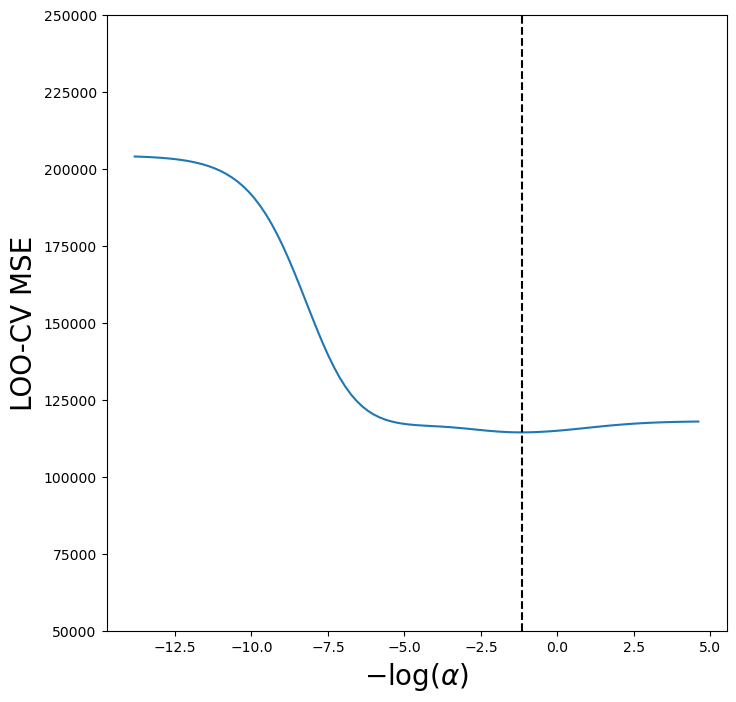

In [17]:
loo_mse = ridgeLOO.cv_results_.mean(0) # Average error for all the samples
loo_fig, ax = subplots(figsize=(8,8))
ax.plot(-np.log(alphas), loo_mse)
ax.axvline(-np.log(ridgeLOO.alpha_), c='k', ls='--')
ax.set_ylim([50000,250000])
ax.set_xlabel(r'$-\log(\alpha)$', fontsize=20)
ax.set_ylabel('LOO-CV MSE', fontsize=20);

In [18]:
loo_mse.min() # This will be a little bit biased

np.float64(114398.78166158483)

### Estimating Out-of-Sample Error for RidgeCV (LOO)
As before, cross-validation has *touched* all of the data in choosing $\alpha$,
so we wrap the entire `RidgeCV` pipeline inside an outer validation split
to get an honest estimate of out-of-sample error.

In [34]:
outer_valid = skm.ShuffleSplit(n_splits=1,
                               test_size=0.25,
                               random_state=1)
ridgeLOO_inner = skl.RidgeCV(alphas=alphas)
pipeLOO_inner = Pipeline(steps=[('scaler', StandardScaler()),
                                ('ridge', ridgeLOO_inner)])

results = skm.cross_validate(pipeLOO_inner,
                             X,
                             Y,
                             cv=outer_valid,
                             scoring='neg_mean_squared_error')
-results['test_score']

array([128869.10607444])

In [41]:
# You want nested?

outer_cv = skm.KFold(n_splits=100, shuffle=True, random_state=10)
ridgeLOO_inner = skl.RidgeCV(alphas=alphas)
pipeLOO_inner = Pipeline(steps=[('scaler', StandardScaler()),
                                ('ridge', ridgeLOO_inner)])

results = skm.cross_validate(pipeLOO_inner,
                             X,
                             Y,
                             cv=outer_cv,
                             scoring='neg_mean_squared_error')
-results['test_score'].mean()

np.float64(115682.50471028053)

## The Lasso
We saw that ridge regression with a wise choice of $\alpha$ can
outperform least squares as well as the null model on the
`Hitters` data set. We now ask whether the lasso can yield
either a more accurate or a more interpretable model than ridge
regression. We use `LassoCV` which fits the lasso along an automatically
chosen regularization path using coordinate descent.

In [42]:
lassoCV = skl.LassoCV(n_alphas=100, cv=kfold)
pipeCV = Pipeline(steps=[('scaler', StandardScaler()),
                         ('lasso', lassoCV)])
pipeCV.fit(X, Y)
tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


np.float64(3.1472370031649866)

We compute the lasso solution path on standardized data to visualize
how coefficients shrink and become exactly zero.

In [23]:
alphas_l = np.logspace(6, -2, 100)

coefs_l = []
for a in alphas_l:
    lasso = skl.Lasso(alpha=a, max_iter=10000)
    pipe = Pipeline(steps=[('scaler', StandardScaler()),
                           ('lasso', lasso)])
    pipe.fit(X, Y)
    coefs_l.append(pipe.named_steps['lasso'].coef_)

soln_path_l = pd.DataFrame(coefs_l,
                           columns=feature_names,
                           index=-np.log(alphas_l))

We can see from the coefficient plot that depending on the choice of
tuning parameter, some of the coefficients will be exactly equal to
zero.

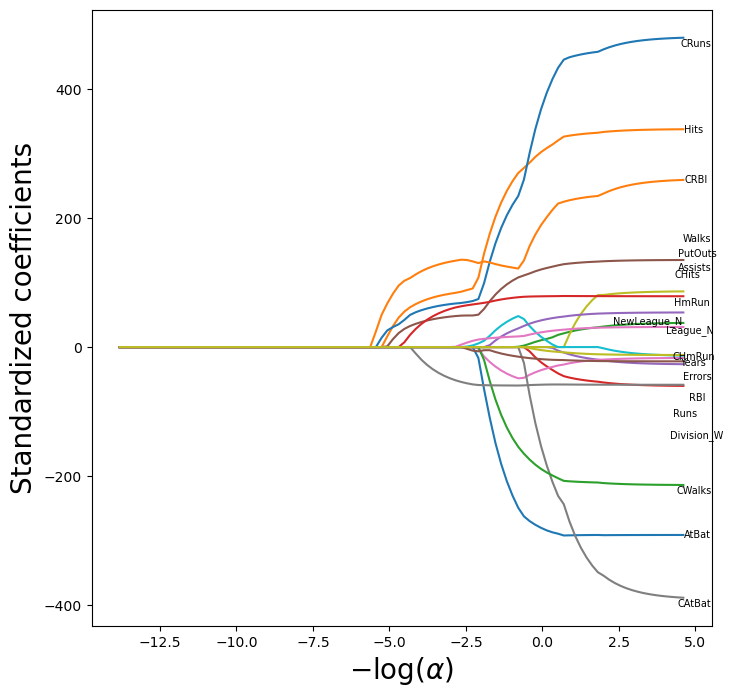

In [24]:
path_fig, ax = subplots(figsize=(8,8))



soln_path_l.plot(ax=ax, legend=False)
x_max = soln_path_l.index[-1]
texts = []
for col in soln_path_l.columns:
    y_end = soln_path_l[col].iloc[-1]
    texts.append(ax.text(x_max, y_end, col, fontsize=7, va='center'))

adjust_text(texts, ax=ax, only_move={'text': 'y'}, force_text=(0.5, 1.0)); # This is like some tools in R for annotating plots with text

#ax.legend(loc='upper left')
ax.set_xlabel(r'$-\log(\alpha)$', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20);



The smallest cross-validated error is lower than the test set MSE of the null model
and of least squares, and very similar to the test MSE of ridge
regression with $\alpha$ chosen by cross-validation.

In [48]:
np.min(tuned_lasso.mse_path_.mean(1))

np.float64(114690.7251180152)

Let's again produce a plot of the cross-validation error.

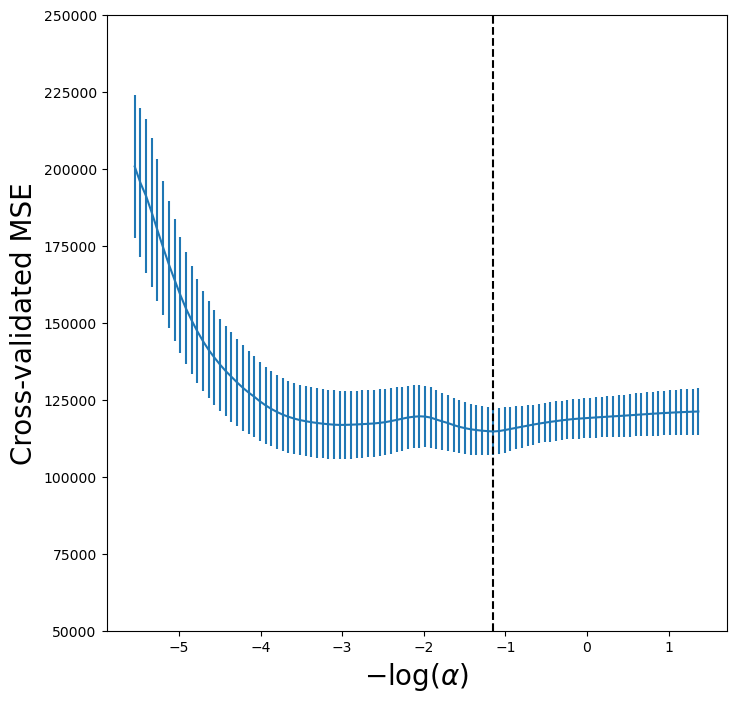

In [50]:
lassoCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls='--')
ax.set_ylim([50000,250000])
ax.set_xlabel(r'$-\log(\alpha)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

However, the lasso has a substantial advantage over ridge regression
in that the resulting coefficient estimates are sparse. Here we see
that some of the 19 coefficient estimates are exactly zero. The lasso
model with $\alpha$ chosen by cross-validation performs variable selection.

In [51]:
tuned_lasso.coef_

array([-210.01024284,  243.45499529,    0.        ,    0.        ,
          0.        ,   97.69407763,  -41.52295051,   -0.        ,
          0.        ,   39.62307229,  205.75339911,  124.55436745,
       -126.30028802,   75.2459413 ,   21.62699585,  -12.0441519 ,
         15.70262131,  -59.50158636,   -0.        ])

In [52]:
np.sum(tuned_lasso.coef_ != 0)

np.int64(13)